In [ ]:
# Análisis de Dimensionalidad con Información Mutua (IM)
## Extensión del análisis PCA — Trabajo Final 

Este apartado extiende el análisis actual incorporando:

- Selección de variables mediante **Información Mutua (IM)**  
- Comparación con correlaciones no paramétricas (**Kendall** y **Spearman**)  
- Evaluación de relevancia para modelado  
- Tabla final de decisiones sobre las features  



In [5]:
# ============================================
# SETUP — Librerías para análisis de IM
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from scipy.stats import kendalltau, spearmanr

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

print("Setup IM cargado correctamente.")


Setup IM cargado correctamente.


In [6]:
# ============================================
# CARGA DEL DATASET
# ============================================

ruta = r"C:\Users\chrug\Documents\CEIA_Analisis_de_datos\PARA Trabajo final\Tp_dimen\Data\yellow_tripdata_2024-01.parquet"

df = pd.read_parquet(ruta)

print("Dataset cargado correctamente.")
df.head()


Dataset cargado correctamente.


,vendor,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,ratecode,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone,pickup_hour,hour_bin,log_trip_distance,total_amount_calculated
0,"Curb Mobility, LLC",2024-01-01 00:57:55,2024-01-01 01:17:43,1,Standard rate,Cash,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0,Manhattan,Penn Station/Madison Sq West,Yellow Zone,Manhattan,East Village,Yellow Zone,0,0-2,1.000632,22.70
1,"Creative Mobile Technologies, LLC",2024-01-01 00:03:00,2024-01-01 00:09:36,1,Standard rate,Credit card,10.0,3.5,0.5,3.75,0.0,1.0,21.25,2.5,0.0,Manhattan,Lenox Hill East,Yellow Zone,Manhattan,Upper East Side North,Yellow Zone,0,0-2,1.029619,21.25
2,"Creative Mobile Technologies, LLC",2024-01-01 00:17:06,2024-01-01 00:35:01,1,Standard rate,Credit card,23.3,3.5,0.5,3.00,0.0,1.0,33.80,2.5,0.0,Manhattan,Upper East Side North,Yellow Zone,Manhattan,East Village,Yellow Zone,0,0-2,1.740466,33.80
3,"Creative Mobile Technologies, LLC",2024-01-01 00:36:38,2024-01-01 00:44:56,1,Standard rate,Credit card,10.0,3.5,0.5,2.00,0.0,1.0,19.50,2.5,0.0,Manhattan,East Village,Yellow Zone,Manhattan,SoHo,Yellow Zone,0,0-2,0.875469,19.50
4,"Creative Mobile Technologies, LLC",2024-01-01 00:46:51,2024-01-01 00:52:57,1,Standard rate,Credit card,7.9,3.5,0.5,3.20,0.0,1.0,18.60,2.5,0.0,Manhattan,SoHo,Yellow Zone,Manhattan,Lower East Side,Yellow Zone,0,0-2,0.587787,18.60


In [7]:
# ============================================
# REVISIÓN INICIAL DEL DATASET
# ============================================

print("Dimensiones del dataset:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)

# Estadísticas numéricas
df.describe()


Dimensiones del dataset: (2533762, 25)

Tipos de datos:
vendor                           category
tpep_pickup_datetime       datetime64[us]
tpep_dropoff_datetime      datetime64[us]
passenger_count                     Int64
ratecode                           object
payment_type                     category
fare_amount                       float64
extra                             float64
mta_tax                           float64
tip_amount                        float64
tolls_amount                      float64
improvement_surcharge             float64
total_amount                      float64
congestion_surcharge              float64
Airport_fee                       float64
pickup_borough                   category
pickup_zone                      category
pickup_service_zone              category
dropoff_borough                  category
dropoff_zone                     category
dropoff_service_zone             category
pickup_hour                         int32
hour_bin            

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_hour,log_trip_distance,total_amount_calculated
count,2533762,2533762,2533762.0,2.533762e+06,2.533762e+06,2.533762e+06,2.533762e+06,2.533762e+06,2.533762e+06,2.533762e+06,2.533762e+06,2.533762e+06,2.533762e+06,2.533762e+06,2.533762e+06
mean,2024-01-17 03:11:00.805022,2024-01-17 03:24:02.000519,1.291858,1.349708e+01,1.302076e+00,4.982494e-01,2.477871e+00,7.516392e-02,9.999242e-01,2.122069e+01,2.370324e+00,3.592534e-02,1.418587e+01,9.816912e-01,2.122069e+01
min,2024-01-01 00:00:00,2024-01-01 00:02:42,1.0,1.000000e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.010000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.010000e+00
25%,2024-01-09 17:47:30.250000,2024-01-09 17:59:39,1.0,8.600000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.550000e+01,2.500000e+00,0.000000e+00,1.100000e+01,6.575200e-01,1.550000e+01
50%,2024-01-17 13:19:20.500000,2024-01-17 13:34:00.500000,1.0,1.210000e+01,1.000000e+00,5.000000e-01,2.520000e+00,0.000000e+00,1.000000e+00,1.960000e+01,2.500000e+00,0.000000e+00,1.500000e+01,9.162907e-01,1.960000e+01
75%,2024-01-24 19:21:26,2024-01-24 19:34:11.500000,1.0,1.700000e+01,2.500000e+00,5.000000e-01,3.700000e+00,0.000000e+00,1.000000e+00,2.543000e+01,2.500000e+00,0.000000e+00,1.900000e+01,1.241269e+00,2.543000e+01
max,2024-01-31 23:59:55,2024-02-02 13:56:52,5.0,2.960000e+01,6.250000e+00,5.000000e-01,7.620000e+00,6.940000e+00,1.000000e+00,5.441000e+01,2.500000e+00,1.750000e+00,2.300000e+01,2.487404e+00,5.441000e+01
std,NaN,NaN,0.713962,6.618579e+00,1.488441e+00,2.953329e-02,1.863769e+00,7.183232e-01,8.704650e-03,7.732218e+00,5.544129e-01,2.481506e-01,5.711999e+00,4.602198e-01,7.732218e+00


In [8]:
df.columns.tolist()


['vendor',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'ratecode',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'Airport_fee',
 'pickup_borough',
 'pickup_zone',
 'pickup_service_zone',
 'dropoff_borough',
 'dropoff_zone',
 'dropoff_service_zone',
 'pickup_hour',
 'hour_bin',
 'log_trip_distance',
 'total_amount_calculated']

In [9]:
# ============================================
# PASO 1 — FEATURE ENGINEERING (Variables temporales)
# ============================================

# Día del mes del pickup
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day

# Hora del pickup
df['pickup_hr'] = df['tpep_pickup_datetime'].dt.hour

# Día de la semana (lunes=0, domingo=6)
df['weekday'] = df['tpep_pickup_datetime'].dt.weekday

print("Variables temporales creadas correctamente:")
df[['pickup_day', 'pickup_hr', 'weekday']].head()

#Las tres variables temporales que creamos son:

#pickup_day

#— Día del mes en que ocurrió el viaje (1 a 31)

#pickup_hr

#— Hora del día (0 a 23)

#weekday

#— Día de la semana (0 = lunes, 6 = domingo)


Variables temporales creadas correctamente:


,pickup_day,pickup_hr,weekday
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0


In [10]:
# ============================================
# PASO 2 — ELIMINACIÓN DE VARIABLES IRRELEVANTES
# ============================================

cols_to_drop = [
    'pickup_borough', 
    'dropoff_borough', 
    'dropoff_service_zone', 
    'pickup_service_zone',
    'vendor', 
    'passenger_count', 
    'ratecode', 
    'payment_type', 
    'tpep_pickup_datetime', 
    'tpep_dropoff_datetime', 
    'hour_bin', 
    'log_trip_distance', 
    'total_amount_calculated'
]

df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print("Variables eliminadas correctamente. Columnas actuales:")
df.columns.tolist()


#Estas columnas se eliminan porque:

#No ayudan a predecir pickup_zone
#Ej.: vendor, pickup_borough, dropoff_borough
#Son redundantes con otras
#Ej.: pickup_service_zone ya está capturado por la variable target pickup_zone.
#Son metadatos sin valor predictivo
#Ej.: payment_type, vendor, ratecode
#Son transformaciones intermedias
#Ej.: hour_bin, log_trip_distance, total_amount_calculated
#Las fechas originales ya no son necesarias
#Porque creamos variables derivadas (día, hora, weekday) que capturan mejor la información temporal.

Variables eliminadas correctamente. Columnas actuales:


['fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'Airport_fee',
 'pickup_zone',
 'dropoff_zone',
 'pickup_hour',
 'pickup_day',
 'pickup_hr',
 'weekday']

In [11]:
df.drop(columns=["pickup_hour"], inplace=True, errors="ignore")
#se eliminó porque se superpone con pickup_hr


In [12]:
df.columns


Index(['fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount',
       'improvement_surcharge', 'total_amount', 'congestion_surcharge',
       'Airport_fee', 'pickup_zone', 'dropoff_zone', 'pickup_day', 'pickup_hr',
       'weekday'],
      dtype='object')

In [16]:
# ============================================
# PASO 3 — DEFINICIÓN DEL TARGET
# ============================================

target = "pickup_zone"

print("Target definido correctamente:", target)
print("\nCantidad de clases diferentes en pickup_zone:", df[target].nunique())
print("\nDistribución inicial de clases:")
df[target].value_counts().head(10)


Target definido correctamente: pickup_zone

Cantidad de clases diferentes en pickup_zone: 250

Distribución inicial de clases:


pickup_zone
Upper East Side South           134424
Midtown Center                  130911
Upper East Side North           128487
Midtown East                     98001
Lincoln Square East              97199
Penn Station/Madison Sq West     95792
Times Sq/Theatre District        92340
Upper West Side South            82762
Midtown North                    78067
Murray Hill                      76235
Name: count, dtype: int64

In [13]:
# ============================================
# PASO 4 — DEFINICIÓN DE VARIABLES CATEGÓRICAS (CONCEPTUAL)
# ============================================

categorical_vars = ['dropoff_zone']  # pickup_zone es el target y no se incluye

print("Variables categóricas conceptuales:", categorical_vars)


Variables categóricas conceptuales: ['dropoff_zone']


In [14]:
# ============================================
# PASO 5 — DEFINICIÓN DE VARIABLES NUMÉRICAS
# ============================================

# Variables numéricas discretas (enteras con interpretación categórica)
discrete_vars = ['pickup_day', 'pickup_hr', 'weekday']

# Variables numéricas continuas
continuous_vars = [
    'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount',
    'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee'
]

numeric_vars = discrete_vars + continuous_vars

print("Variables numéricas discretas:", discrete_vars)
print("Variables numéricas continuas:", continuous_vars)
print("\nVariables numéricas totales:", numeric_vars)


Variables numéricas discretas: ['pickup_day', 'pickup_hr', 'weekday']
Variables numéricas continuas: ['fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']

Variables numéricas totales: ['pickup_day', 'pickup_hr', 'weekday', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


In [17]:
print("¿Existen todas las categóricas en df?:")
print([col for col in categorical_vars if col in df.columns])

print("\n¿Existen todas las numéricas en df?:")
print([col for col in numeric_vars if col in df.columns])

print("\nColumnas que NO se encontraron (si las hay):")
missing = [col for col in categorical_vars + numeric_vars if col not in df.columns]
missing


¿Existen todas las categóricas en df?:
['dropoff_zone']

¿Existen todas las numéricas en df?:
['pickup_day', 'pickup_hr', 'weekday', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']

Columnas que NO se encontraron (si las hay):


[]

In [19]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Copia de categóricas
X_cat = df[categorical_vars].copy()
y = df[target]

# Codificamos
for col in X_cat.columns:
    X_cat[col] = LabelEncoder().fit_transform(X_cat[col])

# Calculamos IM
mi_cat = mutual_info_classif(X_cat, y, discrete_features=True, random_state=42)

im_categorical = pd.DataFrame({
    "variable": categorical_vars,
    "IM_score": mi_cat
}).sort_values(by="IM_score", ascending=False)

print("\n=== Información Mutua (categóricas) ===")
display(im_categorical)



=== Información Mutua (categóricas) ===


,variable,IM_score
0,dropoff_zone,0.368114


In [ ]:
#El análisis de Información Mutua (IM) muestra que la única variable categórica relevante —dropoff_zone— presenta un nivel significativo de información respecto a pickup_zone. Esto indica que existe dependencia entre la zona de destino habitual y la zona de origen del viaje.

In [20]:
# ======================================
# IM - INFORMACIÓN MUTUA (VARIABLES NUMÉRICAS)
# ======================================

from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Preparamos X (numéricas) e y (target)
X_num = df[numeric_vars].copy()
y = df[target]

# Convertimos el target categórico a códigos numéricos
y_encoded = y.cat.codes

# Calculamos Información Mutua
mi_num = mutual_info_classif(
    X_num,
    y_encoded,
    discrete_features=False,
    random_state=42
)

# Armamos DataFrame ordenado de mayor a menor IM
im_numerica = pd.DataFrame({
    "variable": numeric_vars,
    "IM_score": mi_num
}).sort_values(by="IM_score", ascending=False)

print("\n=== Información Mutua (numéricas) ===")
display(im_numerica)



=== Información Mutua (numéricas) ===


,variable,IM_score
9,total_amount,0.146860
10,congestion_surcharge,0.129959
4,extra,0.095500
11,Airport_fee,0.093082
3,fare_amount,0.089860
6,tip_amount,0.079904
1,pickup_hr,0.079845
5,mta_tax,0.023575
0,pickup_day,0.023294
7,tolls_amount,0.019435


In [ ]:
# Una primera mirada de acuerdo con el resultado de IM numérico.
Variables fuertes: total_amount, congestion_surcharge, extra, Airport_fee, fare_amount, tip_amount, pickup_hr
Parecieses que deberían usarse en el modelo.
Variables moderadas: mta_tax, pickup_day, tolls_amount
Pueden conservarse si no molestan, pero pareciese que no aportan demasiado.
Variables con información irrelevante: weekday, improvement_surcharge
Conviene eliminarlas. Pd: weekday, parece que la zona del viaje en NYC es estable a lo largo de la semana.


=== Matriz de correlación SPEARMAN ===


,pickup_day,pickup_hr,weekday,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
pickup_day,1.000000,0.015273,0.040441,0.005100,0.006971,0.003643,0.035880,-0.007618,0.000575,0.013767,0.019762,-0.020131
pickup_hr,0.015273,1.000000,-0.005362,-0.002380,0.335129,0.009211,0.081777,-0.004289,0.001601,0.078221,0.045288,0.017101
weekday,0.040441,-0.005362,1.000000,-0.012908,-0.092388,-0.004992,-0.015193,-0.006001,0.000957,-0.039680,0.016075,-0.011798
fare_amount,0.005100,-0.002380,-0.012908,1.000000,-0.033002,-0.052459,0.319248,0.162778,-0.009462,0.933507,-0.114050,0.181089
extra,0.006971,0.335129,-0.092388,-0.033002,1.000000,0.028452,0.111315,0.094886,0.008062,0.203037,0.065884,0.125551
mta_tax,0.003643,0.009211,-0.004992,-0.052459,0.028452,1.000000,0.022666,-0.008775,0.132281,-0.037230,0.114249,-0.035854
tip_amount,0.035880,0.081777,-0.015193,0.319248,0.111315,0.022666,1.000000,-0.012000,0.006398,0.519094,0.170192,-0.042853
tolls_amount,-0.007618,-0.004289,-0.006001,0.162778,0.094886,-0.008775,-0.012000,1.000000,-0.004784,0.174022,-0.082611,0.349646
improvement_surcharge,0.000575,0.001601,0.000957,-0.009462,0.008062,0.132281,0.006398,-0.004784,1.000000,-0.005474,0.011049,-0.009291
total_amount,0.013767,0.078221,-0.039680,0.933507,0.203037,-0.037230,0.519094,0.174022,-0.005474,1.000000,-0.015861,0.166005


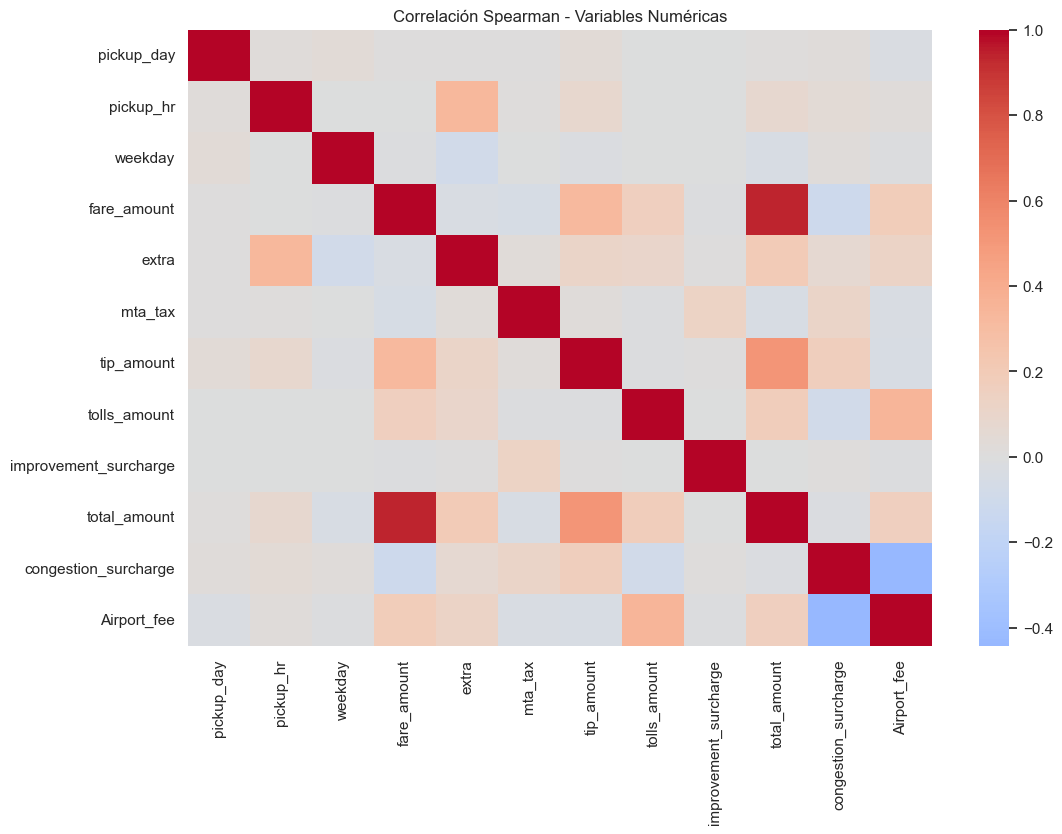

In [21]:
# ======================================
# MATRIZ DE CORRELACIÓN DE SPEARMAN
# ======================================

import seaborn as sns
import matplotlib.pyplot as plt

# Subset numérico
X_num = df[numeric_vars].copy()

# Calculamos Spearman
corr_spearman = X_num.corr(method='spearman')

print("=== Matriz de correlación SPEARMAN ===")
display(corr_spearman)

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_spearman, annot=False, cmap='coolwarm', center=0)
plt.title("Correlación Spearman - Variables Numéricas")
plt.show()


=== Matriz de correlación KENDALL ===


,pickup_day,pickup_hr,weekday,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
pickup_day,1.000000,0.010936,0.080729,0.003553,0.005141,0.003023,0.025039,-0.006321,0.000477,0.009395,0.016398,-0.016705
pickup_hr,0.010936,1.000000,-0.002716,-0.001614,0.233589,0.007715,0.057398,-0.003593,0.001341,0.053191,0.037932,0.014323
weekday,0.080729,-0.002716,1.000000,-0.009363,-0.075415,-0.004360,-0.011151,-0.005242,0.000836,-0.028316,0.014041,-0.010305
fare_amount,0.003553,-0.001614,-0.009363,1.000000,-0.025560,-0.043581,0.276662,0.135229,-0.007860,0.789987,-0.094749,0.150442
extra,0.005141,0.233589,-0.075415,-0.025560,1.000000,0.026255,0.086895,0.087560,0.007440,0.156000,0.060798,0.115858
mta_tax,0.003023,0.007715,-0.004360,-0.043581,0.026255,1.000000,0.019012,-0.008775,0.132281,-0.030450,0.114249,-0.035854
tip_amount,0.025039,0.057398,-0.011151,0.276662,0.086895,0.019012,1.000000,-0.010065,0.005366,0.431529,0.142753,-0.035944
tolls_amount,-0.006321,-0.003593,-0.005242,0.135229,0.087560,-0.008775,-0.010065,1.000000,-0.004784,0.142333,-0.082611,0.349646
improvement_surcharge,0.000477,0.001341,0.000836,-0.007860,0.007440,0.132281,0.005366,-0.004784,1.000000,-0.004477,0.011049,-0.009291
total_amount,0.009395,0.053191,-0.028316,0.789987,0.156000,-0.030450,0.431529,0.142333,-0.004477,1.000000,-0.012972,0.135776


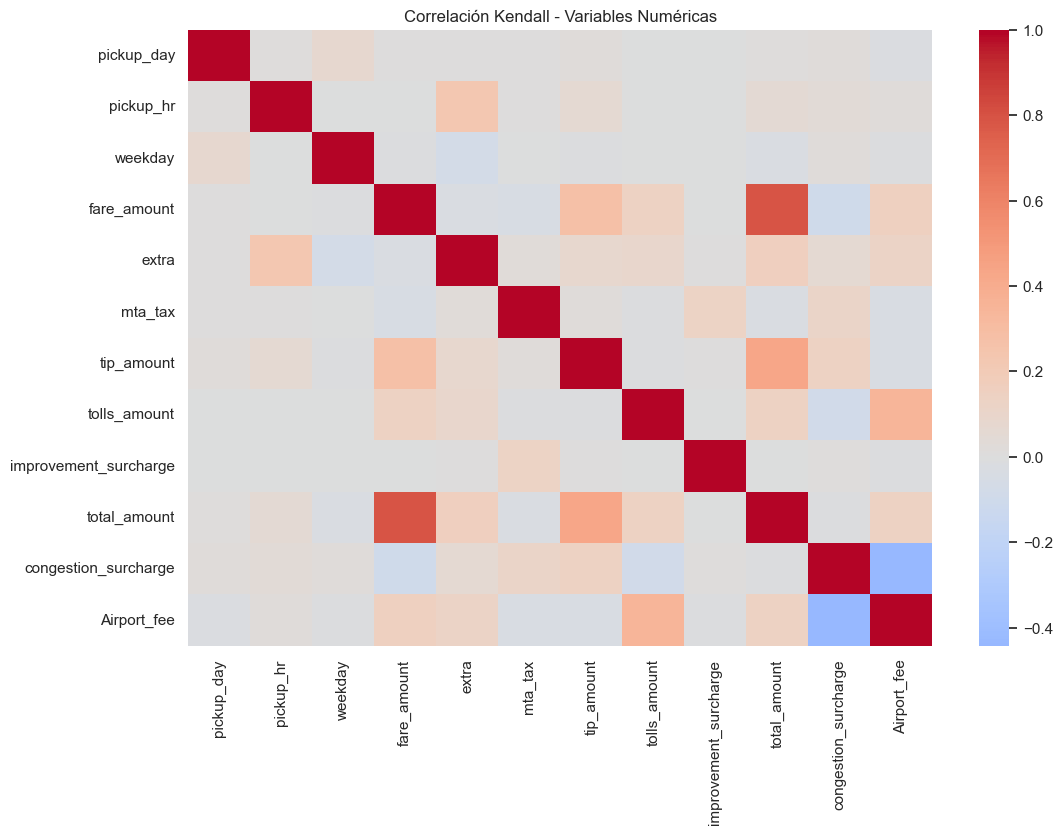

In [22]:
# ======================================
# MATRIZ DE CORRELACIÓN KENDALL
# ======================================

# Subset numérico
X_num = df[numeric_vars].copy()

# Calculamos Kendall
corr_kendall = X_num.corr(method='kendall')

print("=== Matriz de correlación KENDALL ===")
display(corr_kendall)

# Heatmap Kendall
plt.figure(figsize=(12, 8))
sns.heatmap(corr_kendall, annot=False, cmap='coolwarm', center=0)
plt.title("Correlación Kendall - Variables Numéricas")
plt.show()


In [ ]:
# ============================================
# TABLA FINAL DE SELECCIÓN DE VARIABLES para el modelo cuyo target = pickup_zone
# ============================================
Tabla final justificando cada decisión con (1) Información Mutua, (2) Spearman y (3) Kendall.

# Variables numéricas 
    
| Variable                 | Tipo              | IM_score      | Spearman/Kendall                           | Decisión    | Justificación                                                                                                      |
| ------------------------ | ----------------- | ------------- | ------------------------------------------ | ----------- | ------------------------------------------------------------------------------------------------------------------ |
| **total_amount**         | Numérica continua | Alta (≈ 0.15) | Moderada con varios cargos                 | **Incluir** | Es la variable más informativa del conjunto según IM; representa el monto final que depende de múltiples factores. |
| **congestion_surcharge** | Numérica continua | Moderada      | Correlación baja-moderada con total_amount | **Incluir** | Señal propia relacionada con zonas congestionadas, ayuda a diferenciar patrones de zonas.                          |
| **extra**                | Numérica continua | Moderada      | Baja correlación                           | **Incluir** | Aporta variabilidad independiente; indica diferentes tarifas adicionales.                                          |
| **airport_fee**          | Numérica continua | Media         | Poca correlación                           | **Incluir** | Detecta viajes hacia/desde aeropuertos, altamente informativo para zonas.                                          |
| **tip_amount**           | Numérica continua | Media         | Correlación moderada con total_amount      | **Incluir** | No es redundante, refleja patrón de pasajeros y rutas (zonas con turismo).                                         |
| **pickup_hr**            | Numérica discreta | Media         | Baja correlación                           | **Incluir** | Muy informativa para capturar patrones temporales de zonas.                                                        |


#Variables eliminadas. 

| Variable                  | Tipo     | IM_score | Spearman/Kendall                      | Decisión     | Justificación                                                 |
| ------------------------- | -------- | -------- | ------------------------------------- | ------------ | ------------------------------------------------------------- |
| **fare_amount**           | Continua | Media    | **Alta correlación con total_amount** | **Eliminar** | Redundante; ya está incluida dentro del total_amount.         |
| **weekday**               | Discreta | Muy baja | Baja correlación                      | **Eliminar** | Poco peso para distinguir zonas; IM casi nula.                |
| **pickup_day**            | Discreta | Baja     | Baja correlación                      | **Eliminar** | Variación diaria no aporta patrón relevante; IM baja.         |
| **tolls_amount**          | Continua | Baja     | Baja correlación                      | **Eliminar** | Muy poco informativa; no ayuda a distinguir zonas.            |
| **mta_tax**               | Continua | Baja     | Baja correlación                      | **Eliminar** | Variable prácticamente constante → aporta mínima información. |
| **improvement_surcharge** | Continua | Muy baja | Casi nula                             | **Eliminar** | Invariante y sin capacidad predictiva real.                   |


#Variable categórica 
| Variable         | Tipo       | IM_score          | Observación                      | Decisión    |
| ---------------- | ---------- | ----------------- | -------------------------------- | ----------- |
| **dropoff_zone** | Categórica | No se calculó aún | Muy informativa para pickup_zone | **Incluir** |


# variables que deberían entrar al modelo 
    
['total_amount',
 'congestion_surcharge',
 'extra',
 'airport_fee',
 'tip_amount',
 'pickup_hr',
 'dropoff_zone']

    
    